# Verdelingsanalyse velocity-signalen

Deze notebook analyseert per signaal de **statistische verdeling** van de velocity-waarden uit `velocity_timehistory.csv`.

Per signaal wordt bepaald:
- Hoe de empirische verdeling eruitziet (histogram + KDE)
- Of het signaal **normaal verdeeld** is (Shapiro-Wilk / D'Agostino-Pearson + QQ-plot)
- Welke kandidaatverdeling het **best past** (normaal, t, logistisch, scheve normaal, gegeneraliseerde normaal), gerangschikt op het AIC-criterium

De 48 signalen zijn opgebouwd als `Hs{..}_Tp{..}_{methode}_v_{richting}`, met methode ∈ {low, linhigh, quadhigh, DOFbest} en richting ∈ {Z, pitch, roll}.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams['figure.dpi'] = 110
pd.set_option('display.float_format', lambda x: f'{x:.4g}')

CSV_PATH = 'velocity_timehistory.csv'  # pas aan indien nodig

## 1. Data inladen

In [2]:
df = pd.read_csv(CSV_PATH)

# timestep is de index-kolom, de rest zijn signalen
time_col = df.columns[0]
signal_cols = [c for c in df.columns if c != time_col]

print(f'{len(df)} tijdstappen, {len(signal_cols)} signalen')
print(f'NaN-waarden: {df[signal_cols].isna().sum().sum()}')
df.head()

54001 tijdstappen, 48 signalen
NaN-waarden: 0


,timestep,Hs1_Tp4_low_v_Z,Hs1_Tp4_low_v_pitch,Hs1_Tp4_low_v_roll,Hs1_Tp4_linhigh_v_Z,Hs1_Tp4_linhigh_v_pitch,Hs1_Tp4_linhigh_v_roll,Hs1_Tp4_quadhigh_v_Z,Hs1_Tp4_quadhigh_v_pitch,Hs1_Tp4_quadhigh_v_roll,...,Hs8_Tp9_low_v_roll,Hs8_Tp9_linhigh_v_Z,Hs8_Tp9_linhigh_v_pitch,Hs8_Tp9_linhigh_v_roll,Hs8_Tp9_quadhigh_v_Z,Hs8_Tp9_quadhigh_v_pitch,Hs8_Tp9_quadhigh_v_roll,Hs8_Tp9_DOFbest_v_Z,Hs8_Tp9_DOFbest_v_pitch,Hs8_Tp9_DOFbest_v_roll
0,0,-0.002083,0.005008,-2.568e-07,-0.001134,0.004847,4.536e-08,-0.001982,0.004981,-2.282e-07,...,-1.784e-05,0.1071,-0.05773,-3.75e-06,0.1133,-0.05698,-6.04e-06,0.1063,-0.05694,-6.059e-06
1,1,0.008329,0.002268,-2.634e-06,0.008803,0.002126,-2.35e-06,0.008412,0.002245,-2.597e-06,...,-1.145e-05,0.2135,-0.04259,-5.45e-06,0.2272,-0.04264,-7.903e-06,0.2216,-0.04263,-7.785e-06
2,2,0.01204,-0.001605,-1.599e-06,0.01194,-0.001721,-1.326e-06,0.01211,-0.001624,-1.553e-06,...,-4.166e-06,0.287,-0.02208,-6.946e-06,0.3029,-0.02234,-9.063e-06,0.2992,-0.02259,-8.96e-06
3,3,0.01465,-0.006867,-9.193e-07,0.01403,-0.00694,-6.8e-07,0.0147,-0.006881,-8.686e-07,...,-5.337e-06,0.3701,-0.0009568,-4.777e-06,0.385,-0.001197,-4.538e-06,0.3749,-0.0009054,-4.488e-06
4,4,0.01124,-0.0127,-6.835e-07,0.01001,-0.0127,-4.601e-07,0.01125,-0.01271,-6.27e-07,...,-6.886e-06,0.4924,0.01754,-4.284e-06,0.5081,0.01748,-6.098e-06,0.5023,0.01749,-5.963e-06


## 2. Kerngetallen per signaal

Skewness (scheefheid) en kurtosis (staartzwaarte) geven een eerste indicatie van afwijking van normaliteit. Voor een normale verdeling geldt skewness ≈ 0 en (excess) kurtosis ≈ 0.

In [3]:
summary = pd.DataFrame({
    'mean':     df[signal_cols].mean(),
    'std':      df[signal_cols].std(),
    'min':      df[signal_cols].min(),
    'max':      df[signal_cols].max(),
    'skewness': df[signal_cols].apply(lambda s: stats.skew(s.values)),
    'kurtosis': df[signal_cols].apply(lambda s: stats.kurtosis(s.values)),  # excess kurtosis
})
summary

,mean,std,min,max,skewness,kurtosis
Hs1_Tp4_low_v_Z,0.0002511,0.04581,-0.241,0.1798,-0.1545,-0.03176
Hs1_Tp4_low_v_pitch,-4.323e-07,0.02193,-0.1012,0.09512,-0.00288,0.09754
Hs1_Tp4_low_v_roll,6.735e-10,1.727e-06,-7.919e-06,7.603e-06,-0.1445,0.4922
Hs1_Tp4_linhigh_v_Z,0.0002267,0.04315,-0.2378,0.1736,-0.1783,0.02243
Hs1_Tp4_linhigh_v_pitch,-4.006e-07,0.02184,-0.101,0.09511,-0.002311,0.09627
Hs1_Tp4_linhigh_v_roll,8.443e-10,1.595e-06,-8.011e-06,6.733e-06,-0.1934,0.3958
Hs1_Tp4_quadhigh_v_Z,0.0002458,0.04569,-0.2404,0.1795,-0.1545,-0.03518
Hs1_Tp4_quadhigh_v_pitch,-4.281e-07,0.02191,-0.101,0.09507,-0.002619,0.09216
Hs1_Tp4_quadhigh_v_roll,7.249e-10,1.723e-06,-8.038e-06,7.408e-06,-0.1505,0.5033
Hs1_Tp4_DOFbest_v_Z,0.0002353,0.04459,-0.2396,0.1773,-0.1641,-0.00984


## 3. Normaliteitstoets per signaal

We toetsen elk signaal op normaliteit. Bij grote datasets (hier ~54.000 punten) is de **Shapiro-Wilk-test** niet betrouwbaar/toepasbaar (en uiterst gevoelig), daarom gebruiken we de **D'Agostino-Pearson** `normaltest`, die skewness en kurtosis combineert.

> **Let op:** bij zeer grote n verwerpt elke formele toets normaliteit al bij minieme afwijkingen. De p-waarde is dus indicatief; kijk vooral ook naar skewness, kurtosis en de QQ-plots.

In [4]:
rows = []
for c in signal_cols:
    x = df[c].values
    stat, p = stats.normaltest(x)  # D'Agostino-Pearson
    rows.append({
        'signal': c,
        'normaltest_stat': stat,
        'p_value': p,
        'normaal_bij_alpha=0.05': p > 0.05,
    })

normality = pd.DataFrame(rows).set_index('signal')
print(f"Aantal signalen dat normaliteit NIET verwerpt (p>0.05): "
      f"{normality['normaal_bij_alpha=0.05'].sum()} van {len(normality)}")
normality

Aantal signalen dat normaliteit NIET verwerpt (p>0.05): 0 van 48


,normaltest_stat,p_value,normaal_bij_alpha=0.05
signal,,,
Hs1_Tp4_low_v_Z,214.8,2.318e-47,False
Hs1_Tp4_low_v_pitch,19.7,5.274e-05,False
Hs1_Tp4_low_v_roll,542.8,1.34e-118,False
Hs1_Tp4_linhigh_v_Z,282.8,3.957e-62,False
Hs1_Tp4_linhigh_v_pitch,19.19,6.802e-05,False
Hs1_Tp4_linhigh_v_roll,579.2,1.675e-126,False
Hs1_Tp4_quadhigh_v_Z,215.2,1.871e-47,False
Hs1_Tp4_quadhigh_v_pitch,17.68,0.0001449,False
Hs1_Tp4_quadhigh_v_roll,571.6,7.727e-125,False


## 4. Best passende verdeling per signaal

Voor elk signaal fitten we een set kandidaatverdelingen via maximum-likelihood en vergelijken we ze met het **AIC** (Akaike Information Criterion; lager = beter). Zo zien we of een niet-normale verdeling het signaal beter beschrijft.

Kandidaten:
- `norm` — normaal
- `t` — Student-t (zwaardere staarten)
- `logistic` — logistisch (zwaardere staarten dan normaal)
- `skewnorm` — scheve normaal (asymmetrie)
- `gennorm` — gegeneraliseerde normaal (flexibele staartvorm)

In [5]:
CANDIDATES = {
    'norm':     stats.norm,
    't':        stats.t,
    'logistic': stats.logistic,
    'skewnorm': stats.skewnorm,
    'gennorm':  stats.gennorm,
}

def aic(log_lik, k):
    return 2 * k - 2 * log_lik

def best_fit(x):
    """Fit alle kandidaten en geef AIC per verdeling + de beste terug."""
    results = {}
    for name, dist in CANDIDATES.items():
        try:
            params = dist.fit(x)
            ll = np.sum(dist.logpdf(x, *params))
            if not np.isfinite(ll):
                continue
            results[name] = {'aic': aic(ll, len(params)), 'params': params}
        except Exception:
            continue
    best = min(results, key=lambda n: results[n]['aic'])
    return best, results

best_rows = []
fit_cache = {}
for c in signal_cols:
    x = df[c].values
    best, results = best_fit(x)
    fit_cache[c] = results
    aic_norm = results.get('norm', {}).get('aic', np.nan)
    aic_best = results[best]['aic']
    best_rows.append({
        'signal': c,
        'best_dist': best,
        'AIC_best': aic_best,
        'AIC_norm': aic_norm,
        'delta_AIC_(norm-best)': aic_norm - aic_best,  # 0 = normaal is beste
    })

best_fit_df = pd.DataFrame(best_rows).set_index('signal')
print('Verdeling van best passende verdelingen:')
print(best_fit_df['best_dist'].value_counts())
best_fit_df

Verdeling van best passende verdelingen:
best_dist
gennorm     16
skewnorm    12
t           12
logistic     8
Name: count, dtype: int64


,best_dist,AIC_best,AIC_norm,delta_AIC_(norm-best)
signal,,,,
Hs1_Tp4_low_v_Z,skewnorm,-1.799e+05,-1.797e+05,200.3
Hs1_Tp4_low_v_pitch,t,-2.593e+05,-2.593e+05,16.12
Hs1_Tp4_low_v_roll,gennorm,-1.28e+06,-1.28e+06,372
Hs1_Tp4_linhigh_v_Z,skewnorm,-1.865e+05,-1.862e+05,270.9
Hs1_Tp4_linhigh_v_pitch,t,-2.597e+05,-2.597e+05,15.66
Hs1_Tp4_linhigh_v_roll,skewnorm,-1.289e+06,-1.288e+06,346.6
Hs1_Tp4_quadhigh_v_Z,skewnorm,-1.802e+05,-1.8e+05,200
Hs1_Tp4_quadhigh_v_pitch,t,-2.594e+05,-2.594e+05,14.24
Hs1_Tp4_quadhigh_v_roll,gennorm,-1.28e+06,-1.28e+06,381.7


## 5. Visuele inspectie per signaal

Voor een gekozen signaal: histogram met de gefitte normale en best-passende verdeling ernaast, plus een QQ-plot tegen de normale verdeling. Pas `SIGNAL` aan om een ander signaal te bekijken.

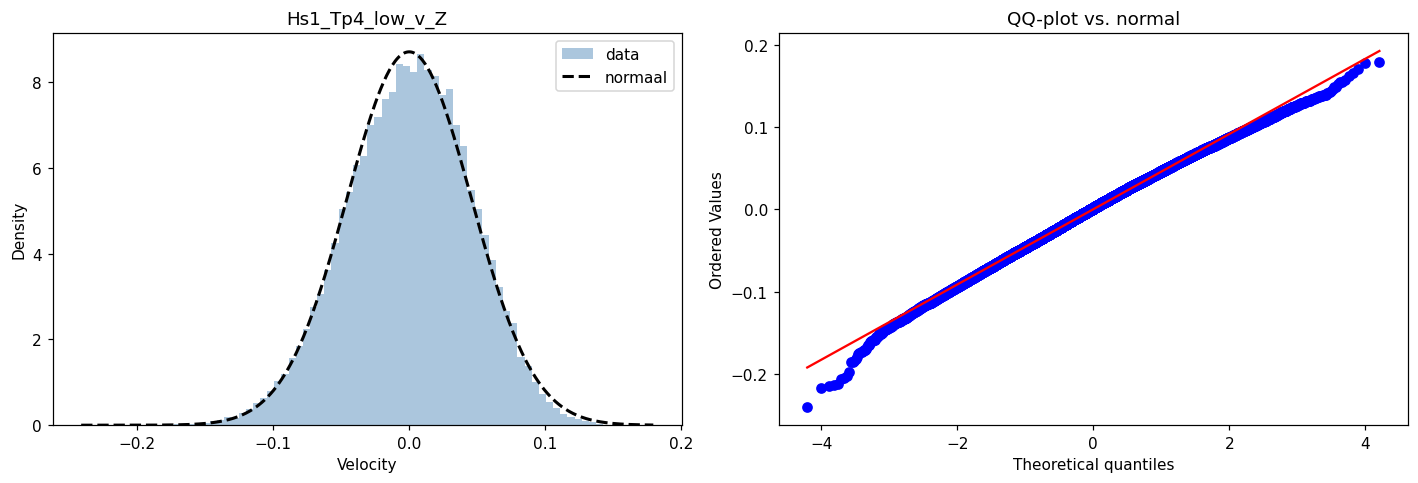

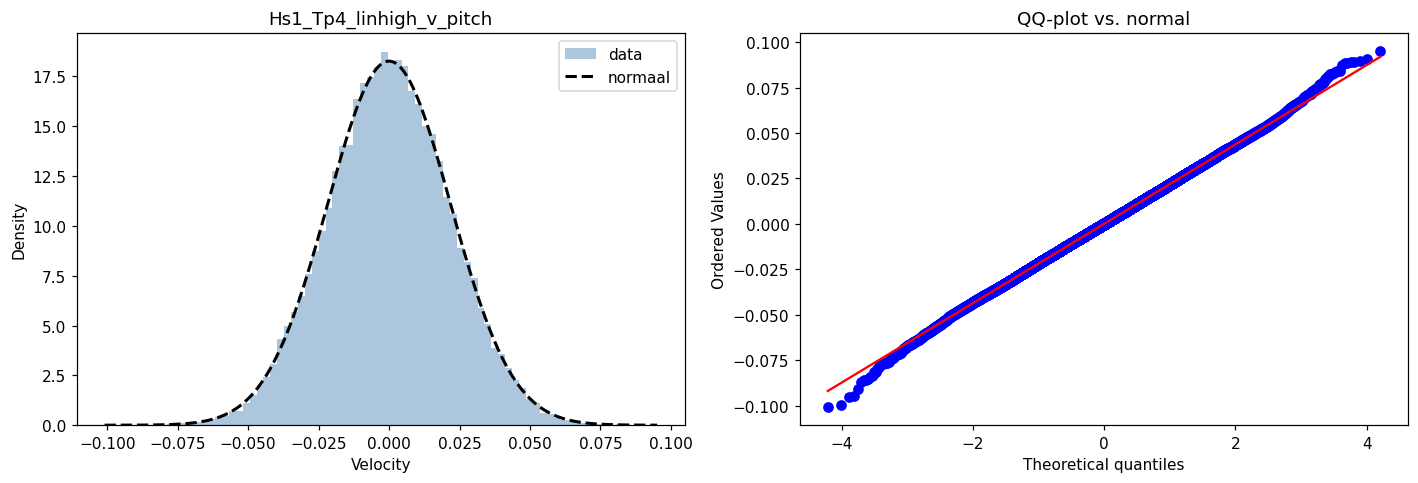

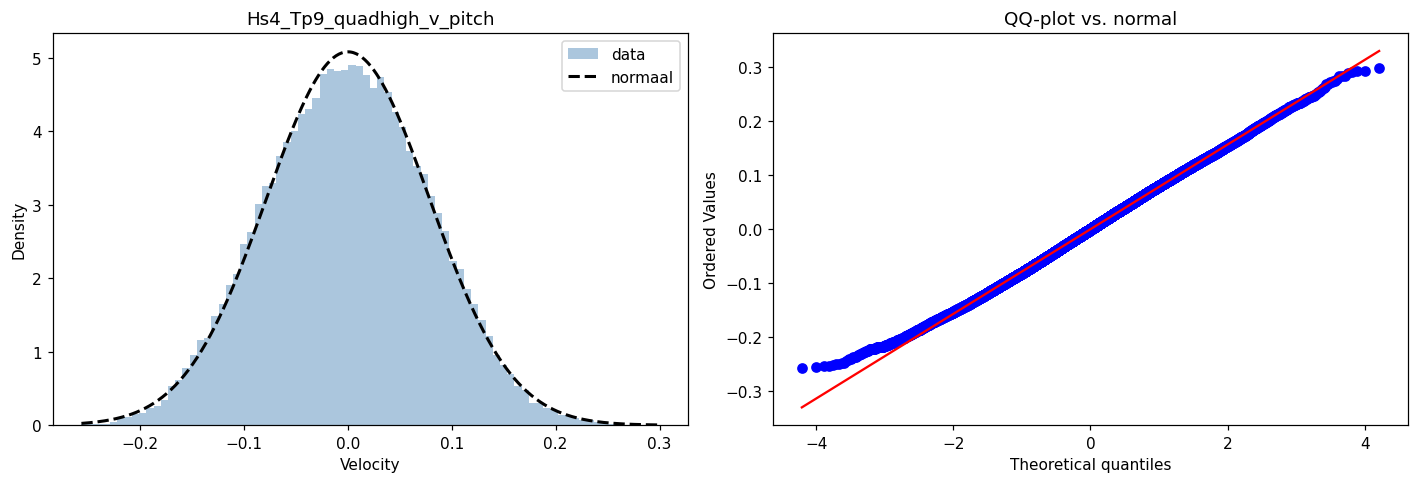

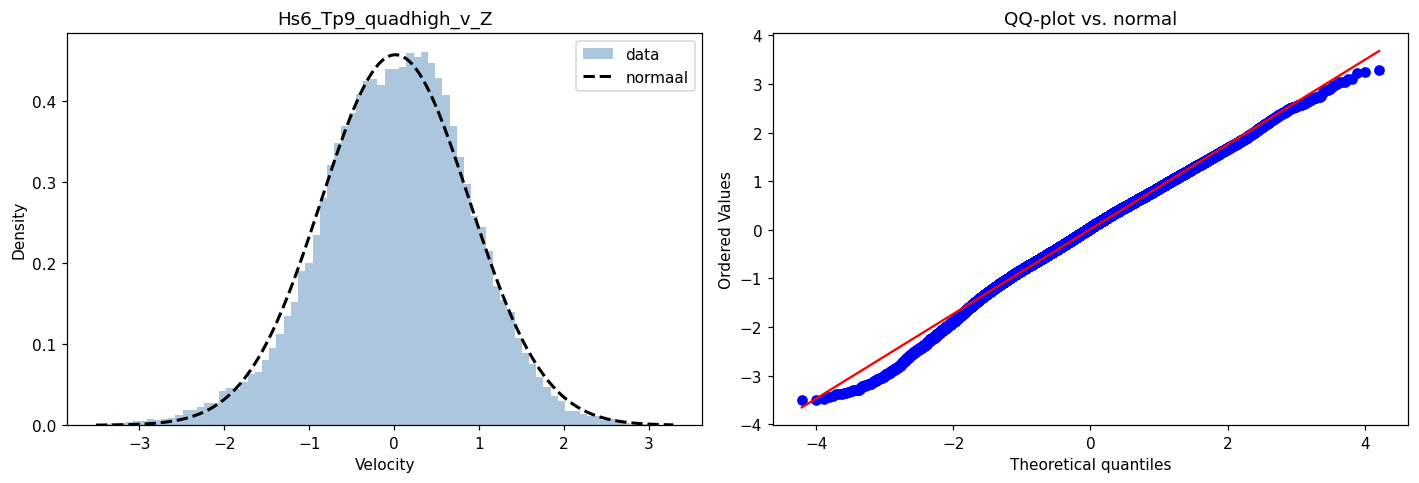

In [19]:
def plot_signal(signal):
    x = df[signal].values
    results = fit_cache[signal]
    best = best_fit_df.loc[signal, 'best_dist']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

    # Histogram + fits
    ax1.hist(x, bins=80, density=True, alpha=0.45, color='steelblue', label='data')
    xs = np.linspace(x.min(), x.max(), 400)
    norm_params = results['norm']['params']
    ax1.plot(xs, stats.norm.pdf(xs, *norm_params), 'k--', lw=2, label='normaal')
    # if best != 'norm':
    #     bp = results[best]['params']
    #     ax1.plot(xs, CANDIDATES[best].pdf(xs, *bp), 'r-', lw=2, label=f'best: {best}')
    ax1.set_title(f'{signal}')
    ax1.set_xlabel('Velocity'); ax1.set_ylabel('Density'); ax1.legend()

    # QQ-plot tegen normaal
    stats.probplot(x, dist='norm', plot=ax2)
    ax2.set_title('QQ-plot vs. normal')
    plt.tight_layout(); plt.show()

SIGNAL = signal_cols[0]  # <-- pas aan om een ander signaal te bekijken
plot_signal(SIGNAL)
SIGNAL = signal_cols[4]  # <-- pas aan om een ander signaal te bekijken
plot_signal(SIGNAL)
SIGNAL = signal_cols[19]  # <-- pas aan om een ander signaal te bekijken
plot_signal(SIGNAL)
SIGNAL = signal_cols[30]  # <-- pas aan om een ander signaal te bekijken
plot_signal(SIGNAL)

### Alle signalen achter elkaar (optioneel)
Uncomment om voor elk signaal de plots te genereren.

In [7]:
# for c in signal_cols:
#     plot_signal(c)

## 6. Samenvatting opslaan

Combineert kerngetallen, normaliteitstoets en best-fit in één overzicht en schrijft het naar CSV.

In [8]:
overview = summary.join(normality).join(best_fit_df)
overview.to_csv('velocity_distribution_summary.csv')
print('Opgeslagen als velocity_distribution_summary.csv')
overview

Opgeslagen als velocity_distribution_summary.csv


,mean,std,min,max,skewness,kurtosis,normaltest_stat,p_value,normaal_bij_alpha=0.05,best_dist,AIC_best,AIC_norm,delta_AIC_(norm-best)
Hs1_Tp4_low_v_Z,0.0002511,0.04581,-0.241,0.1798,-0.1545,-0.03176,214.8,2.318e-47,False,skewnorm,-1.799e+05,-1.797e+05,200.3
Hs1_Tp4_low_v_pitch,-4.323e-07,0.02193,-0.1012,0.09512,-0.00288,0.09754,19.7,5.274e-05,False,t,-2.593e+05,-2.593e+05,16.12
Hs1_Tp4_low_v_roll,6.735e-10,1.727e-06,-7.919e-06,7.603e-06,-0.1445,0.4922,542.8,1.34e-118,False,gennorm,-1.28e+06,-1.28e+06,372
Hs1_Tp4_linhigh_v_Z,0.0002267,0.04315,-0.2378,0.1736,-0.1783,0.02243,282.8,3.957e-62,False,skewnorm,-1.865e+05,-1.862e+05,270.9
Hs1_Tp4_linhigh_v_pitch,-4.006e-07,0.02184,-0.101,0.09511,-0.002311,0.09627,19.19,6.802e-05,False,t,-2.597e+05,-2.597e+05,15.66
Hs1_Tp4_linhigh_v_roll,8.443e-10,1.595e-06,-8.011e-06,6.733e-06,-0.1934,0.3958,579.2,1.675e-126,False,skewnorm,-1.289e+06,-1.288e+06,346.6
Hs1_Tp4_quadhigh_v_Z,0.0002458,0.04569,-0.2404,0.1795,-0.1545,-0.03518,215.2,1.871e-47,False,skewnorm,-1.802e+05,-1.8e+05,200
Hs1_Tp4_quadhigh_v_pitch,-4.281e-07,0.02191,-0.101,0.09507,-0.002619,0.09216,17.68,0.0001449,False,t,-2.594e+05,-2.594e+05,14.24
Hs1_Tp4_quadhigh_v_roll,7.249e-10,1.723e-06,-8.038e-06,7.408e-06,-0.1505,0.5033,571.6,7.727e-125,False,gennorm,-1.28e+06,-1.28e+06,381.7
Hs1_Tp4_DOFbest_v_Z,0.0002353,0.04459,-0.2396,0.1773,-0.1641,-0.00984,239.4,1.023e-52,False,skewnorm,-1.829e+05,-1.827e+05,227.6
